In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("../data/raw/EuroSAT_RGB")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Found {len(CLASSES)} classes: {CLASSES}")

Found 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


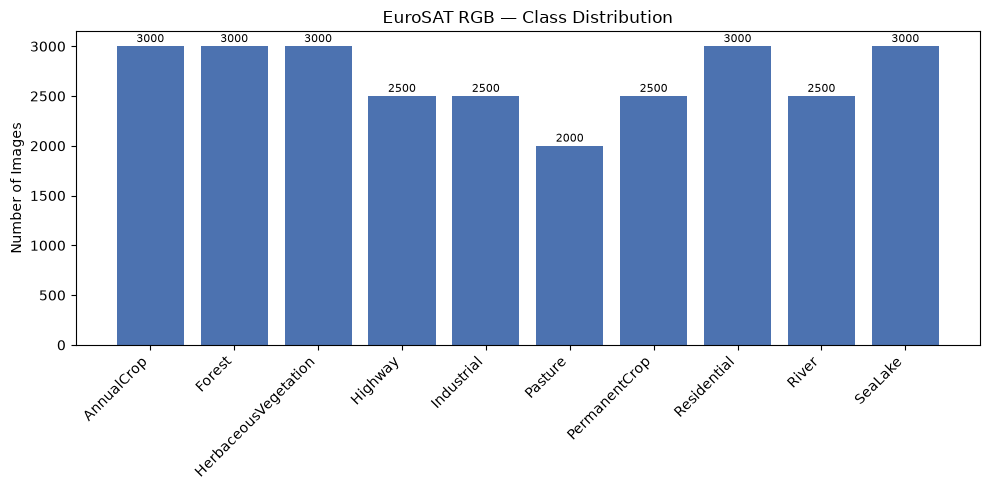

{'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}

Max:Min ratio = 3000:2000 = 1.50


In [6]:
class_counts = {cls: len(list((DATA_DIR / cls).glob("*.jpg"))) for cls in CLASSES}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), color="#4C72B0")
ax.set_title("EuroSAT RGB — Class Distribution")
ax.set_ylabel("Number of Images")
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.keys(), rotation=45, ha="right")
for bar in bars:
    height = bar.get_height()
    ax.annotate(str(height), xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

print(class_counts)
counts = list(class_counts.values())
print(f"\nMax:Min ratio = {max(counts)}:{min(counts)} = {max(counts)/min(counts):.2f}")

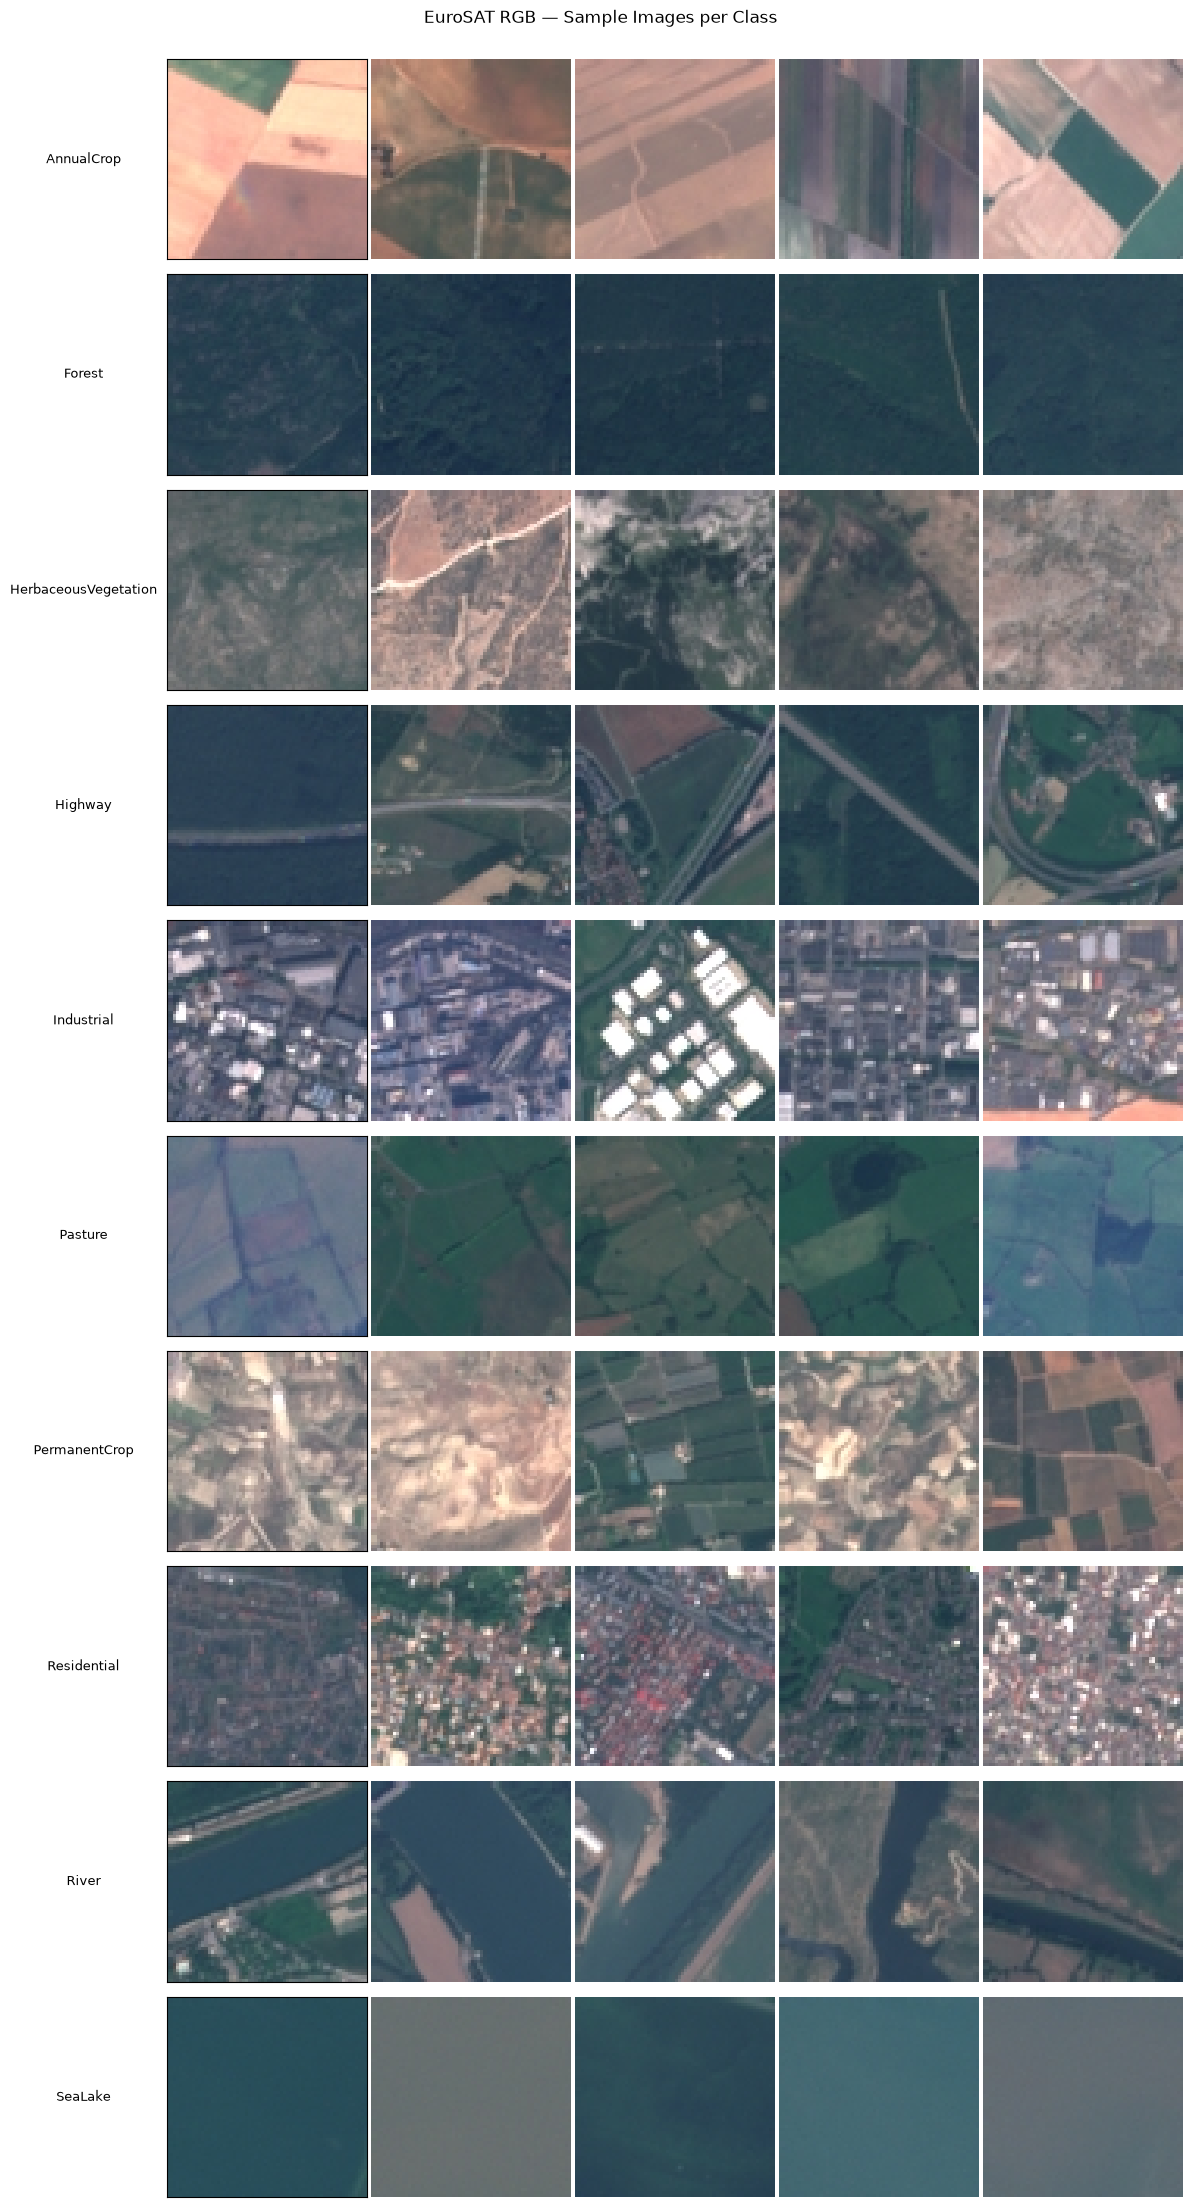

In [3]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(12, 2.2 * len(CLASSES)))

rng = np.random.default_rng(seed=42)

for row, cls in enumerate(CLASSES):
    img_paths = list((DATA_DIR / cls).glob("*.jpg"))
    sample_paths = rng.choice(img_paths, size=5, replace=False)
    for col, img_path in enumerate(sample_paths):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=9)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(cls, fontsize=9, rotation=0, labelpad=60, va="center")

plt.suptitle("EuroSAT RGB — Sample Images per Class", y=1.001)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

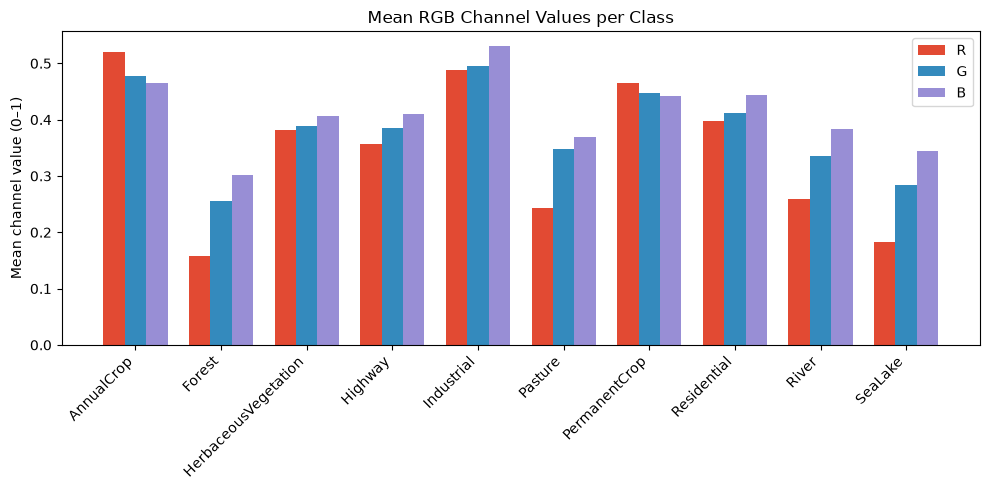

AnnualCrop                mean RGB = [0.52  0.478 0.465]
Forest                    mean RGB = [0.158 0.256 0.302]
HerbaceousVegetation      mean RGB = [0.382 0.388 0.406]
Highway                   mean RGB = [0.357 0.385 0.41 ]
Industrial                mean RGB = [0.488 0.495 0.53 ]
Pasture                   mean RGB = [0.244 0.348 0.37 ]
PermanentCrop             mean RGB = [0.466 0.447 0.441]
Residential               mean RGB = [0.398 0.411 0.444]
River                     mean RGB = [0.259 0.335 0.383]
SeaLake                   mean RGB = [0.182 0.284 0.345]


In [4]:
def compute_channel_stats(img_paths, sample_size=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(seed=42)
    if len(img_paths) > sample_size:
        img_paths = rng.choice(img_paths, size=sample_size, replace=False)

    means = []
    for img_path in img_paths:
        arr = np.array(Image.open(img_path)) / 255.0
        means.append(arr.reshape(-1, 3).mean(axis=0))
    means = np.array(means)
    return means.mean(axis=0), means.std(axis=0)

rng = np.random.default_rng(seed=42)
channel_stats = {}
for cls in CLASSES:
    img_paths = list((DATA_DIR / cls).glob("*.jpg"))
    mean, std = compute_channel_stats(img_paths, rng=rng)
    channel_stats[cls] = {"mean_rgb": mean.tolist(), "std_rgb": std.tolist()}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASSES))
width = 0.25
colors = ["#E24A33", "#348ABD", "#988ED5"]
labels = ["R", "G", "B"]
for i in range(3):
    values = [channel_stats[cls]["mean_rgb"][i] for cls in CLASSES]
    ax.bar(x + (i - 1) * width, values, width, label=labels[i], color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_ylabel("Mean channel value (0–1)")
ax.set_title("Mean RGB Channel Values per Class")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rgb_channel_stats.png", dpi=150)
plt.show()

for cls, stats in channel_stats.items():
    print(f"{cls:25s} mean RGB = {np.round(stats['mean_rgb'], 3)}")

In [5]:
with open("../reports/dataset_verification.json") as f:
    verification_report = json.load(f)

print(f"Corrupted images found: {verification_report['num_corrupted']}")
print(f"Unique dimensions: {verification_report['unique_dimensions']}")
print(f"Unique channel counts: {verification_report['unique_channel_counts']}")

Corrupted images found: 0
Unique dimensions: [[64, 64]]
Unique channel counts: [3]


## EDA Interpretation

### Class Distribution
Mild class imbalance, with a max:min ratio of 1.50 (Pasture at 2,000 
images vs. five classes — AnnualCrop, Forest, HerbaceousVegetation, 
Residential, SeaLake — at 3,000 each). This is not severe enough to 
require correction at this stage. We'll proceed without weighted loss 
or oversampling for the baseline model, and revisit only if the 
confusion matrix in Phase 11 shows Pasture being systematically 
underpredicted.

### Visual Class Separability
At 64×64 resolution, no pair of classes stood out as obviously confusable 
by eye in the sample gallery — the low resolution limits how much fine 
visual detail is available to judge by. This doesn't rule out confusion; 
it just means we can't predict it visually with confidence. We'll rely 
on the RGB channel analysis below and the actual confusion matrix 
(Phase 11) to identify real confusion patterns, rather than guessing 
from the gallery alone.

### RGB Channel Statistics
Two pairs stand out numerically as worth watching:
- **AnnualCrop and PermanentCrop** have nearly identical mean RGB profiles
  ([0.52, 0.478, 0.465] vs [0.466, 0.447, 0.441]), both red-dominant — 
  expected, since both represent cultivated cropland, and likely differ 
  more in texture/pattern than color alone.
- **River and Pasture** are numerically close ([0.259, 0.335, 0.383] vs 
  [0.244, 0.348, 0.37]) despite being conceptually distinct (water vs. 
  grassland) — a less intuitive result worth checking against the actual 
  confusion matrix later.

Industrial is the brightest class overall ([0.488, 0.495, 0.53]), 
consistent with reflective built surfaces (concrete, rooftops). Forest 
and SeaLake are the two darkest classes, though SeaLake shows a stronger 
blue shift that should help separate the two.

### Data Quality
0 corrupted images out of 27,000. All images consistently 64×64, 
3-channel RGB — confirmed independently by both the automated 
verification script (Phase 3) and this notebook (Cell 5), with 
matching results.

### Decision Going Forward
Proceeding without class weighting for the baseline model, given the 
mild 1.5:1 imbalance. Based on RGB similarity (not visual inspection, 
since no clear pattern was visible at this resolution), we'll pay 
particular attention to AnnualCrop/PermanentCrop and River/Pasture 
confusion when we reach Phase 11 (Detailed Evaluation) and Phase 13 
(Error Analysis).